<a href="https://colab.research.google.com/github/vera2005/MLCV_course1/blob/main/Lesson2/ML_COURSE_Lesson2_FULL0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Импорт всего подряд, предположительно нужного

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

In [ ]:
# Загрузка через Hugging Face (надёжнее, чем sklearn)
!pip install -q datasets

# 1. Градиентый спуск

Ручная реализация

In [ ]:
#Генерирует 100 случайных чисел из равномерного распределения на интервале [0, 1) * 10
X_demo = np.random.rand(100, 1) * 10
# y_demo — это целевая переменная, вычисленная по формуле:y = 2 * X + 5 + шум
y_demo = 2.0 * X_demo + 5.0 + np.random.randn(100, 1) * 0.5

w, b = np.random.randn(1), np.random.randn(1)
lr = 0.01

for epoch in range(5):
    y_pred = X_demo * w + b
    loss = np.mean((y_demo - y_pred) ** 2)
    # из производныч MSE по w и b:
    dw = -2 * np.mean(X_demo * (y_demo - y_pred))
    db = -2 * np.mean(y_demo - y_pred)

    w -= lr * dw
    b -= lr * db
    print(f"Эпоха {epoch}: loss = {loss:.4f}")

Эпоха 0: loss = 200.1087
Эпоха 1: loss = 29.8981
Эпоха 2: loss = 6.7965
Эпоха 3: loss = 3.6366
Эпоха 4: loss = 3.1801


Визуализация того, как за 5 эпох мы подогнали параметры прямой для описания сгенерированных данных

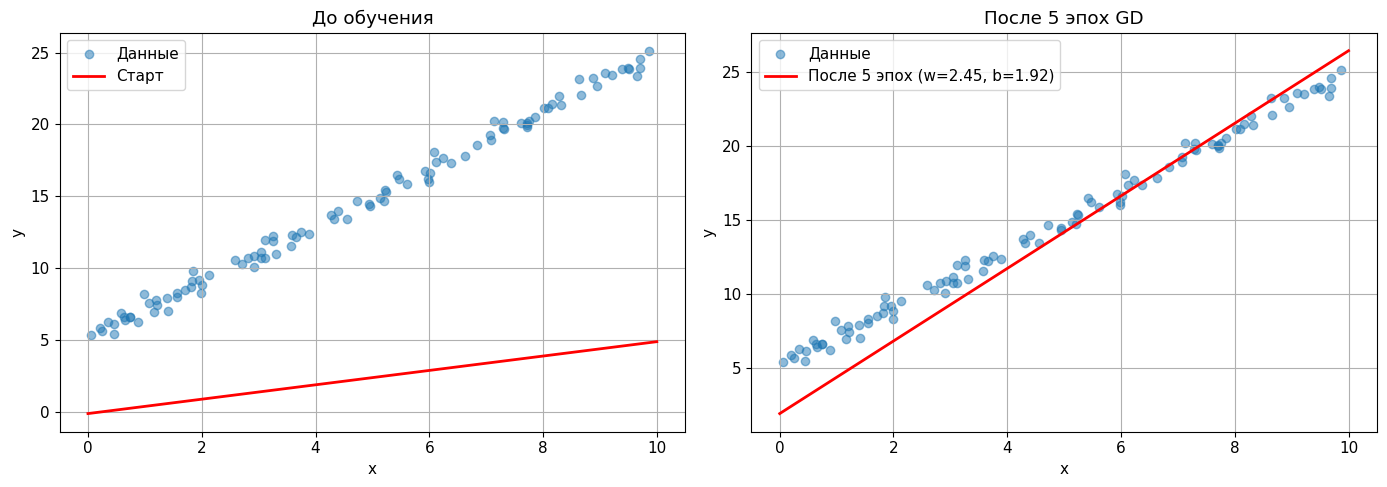

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, 10, 100).reshape(-1, 1)

axes[0].scatter(X_demo, y_demo, alpha=0.5, label='Данные')
axes[0].plot(x_line, x_line * 0.5 - 0.1, color='red', linewidth=2, label='Старт')
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("До обучения"); axes[0].legend()

axes[1].scatter(X_demo, y_demo, alpha=0.5, label='Данные')
axes[1].plot(x_line, x_line * w + b, color='red', linewidth=2,
             label=f'После 5 эпох (w={w[0]:.2f}, b={b[0]:.2f})')
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("После 5 эпох GD"); axes[1].legend()

plt.tight_layout(); plt.show()

#2. Линейная регрессия
Решаем задачу предсказания цен на дома в Калифорнии

В выбранном датасете california_housing приведены данные о районах, на основе которых можно предположить какая будет цена у дома в этом районе

1. Загружаем датасет в переременную df и смотрим на его форму: (число образцов, число признаков)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("gvlassis/california_housing")
df = dataset['train'].to_pandas()

print("Форма датасета:", df.shape)
print("Колонки:", list(df.columns))

Форма датасета: (16640, 9)
Колонки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


Признаки:
1) MedInc	(Median Income) - 	Медианный доход жителей района
2)	HouseAge	(House Age) -	Медианный возраст домов в районе	годы
3)	AveRooms	(Average Rooms) - 	Среднее число комнат на дом	штук
4)	AveBedrms	(Average Bedrooms) -	Среднее число спален на дом	штук
5)	Population	-	Население района	человек
6)	AveOccup	(Average Occupancy) - 	Среднее число жителей на дом	человек
7)	Latitude	-	Географическая широта района	градусы
8)	Longitude	-	Географическая долгота района	градусы
9)	MedHouseVal	(Median House Value) - Медианная стоимость дома (целевая переменная)

Вывод признаков

In [ ]:
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']
target_name = 'MedHouseVal'

print("ПРИЗНАКИ (что знаем о районе):")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

print(f"\nЦЕЛЕВАЯ ПЕРЕМЕННАЯ (что предсказываем): {target_name}")
print(f"  Единицы: 100 000 $  (2.5 = 250 000 $)")

ПРИЗНАКИ (что знаем о районе):
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

ЦЕЛЕВАЯ ПЕРЕМЕННАЯ (что предсказываем): MedHouseVal
  Единицы: 100 000 $  (2.5 = 250 000 $)


2. Вывод парочки образцов

In [ ]:
print("\nПЕРВЫЕ 5 ОБЪЕКТОВ (как таблица):")
#.head(5) — метод pandas, который возвращает первые 5 строк таблицы.
#.copy() создаёт полную независимую копию.
#Теперь мы можем менять sample как угодно — df останется неизменным.
sample = df.head(5).copy()

sample.index = range(1, 6)

#.round(3) — округляет все числовые значения в таблице до 3 знаков после запятой
print(sample.round(3))


ПЕРВЫЕ 5 ОБЪЕКТОВ (как таблица):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
1   8.325      41.0     6.984      1.024       322.0     2.556     37.88   
2   8.301      21.0     6.238      0.972      2401.0     2.110     37.86   
3   7.257      52.0     8.288      1.073       496.0     2.802     37.85   
4   5.643      52.0     5.817      1.073       558.0     2.548     37.85   
5   3.846      52.0     6.282      1.081       565.0     2.181     37.85   

   Longitude  MedHouseVal  
1    -122.23        4.526  
2    -122.22        3.585  
3    -122.24        3.521  
4    -122.25        3.413  
5    -122.25        3.422  


3. Разбивка на выборки

In [ ]:
X = df[feature_names].values
y = df[target_name].values

print("X:", X.shape, "y:", y.shape)

X: (16640, 8) y: (16640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape} ({len(X_test)/len(X)*100:.0f}%)")

Train: (13312, 8) (80%)
Test:  (3328, 8) (20%)


4. Предобработка данных: StandardScaler приводит все признаки к среднему 0 и std 1. Без этого нейросеть будет плохо учиться: Population в тысячах, MedInc — единицы, они несопоставимы.

StandardScaler — это инструмент из sklearn, который преобразует каждый признак так, чтобы у него было:

среднее = 0

стандартное отклонение = 1

x_new = (x - mean) / std



In [ ]:
scaler = StandardScaler()
#scaler вычисляет mean и std по train-выборке и запоминает их.
#transform: тут же применяет формулу к X_train.
#Результат: X_train становится масштабированным.
X_train = scaler.fit_transform(X_train)


#transform: использует те же самые mean и std, которые были вычислены на train.
#Результат: X_test масштабируется с параметрами train.
# избегаем утечки данных
X_test = scaler.transform(X_test)

После масштабирования:
  Среднее (первые 3 признака): [-0.  0.  0.]
  Std    (первые 3 признака):  [1. 1. 1.]


**5. Создаем нейросеть!**

In [ ]:
n_features = X_train.shape[1] # =8

model = Sequential([
    Dense(1, input_shape=(n_features,), activation='linear')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

**6. Compile**

compile настраивает три вещи: optimizer — как обновлять веса (Adam), loss — что минимизируем (MSE), metrics — что показываем (MAE, средняя абсолютная ошибка в тех же единицах, что и цена). Adam сам подбирает шаг для каждого веса, поэтому работает "из коробки"

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

**7. fit — обучение**

fit запускает обучение.

epochs=50 — 50 проходов по данным.

batch_size=32 — на каждой итерации берём 32 объекта (mini-batch GD).

validation_split=0.2 — 20% обучающих данных откладываем для валидации, чтобы видеть, как модель учится, и не переобучается ли.


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
)

print("Обучение завершено!")

Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 4/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 5/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 6/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 7/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 8/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5553 - mae: 0.5413 - val_loss: 0.5566 - val_mae: 0.5405
Epoch 9/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

8. Визуализация процесса обучения

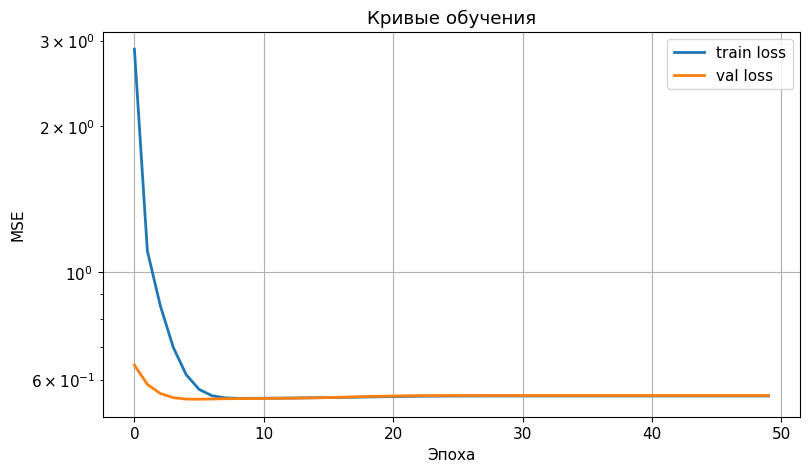

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(history.history['loss'], label='train loss', linewidth=2)
ax.plot(history.history['val_loss'], label='val loss', linewidth=2)
ax.set_xlabel("Эпоха")
ax.set_ylabel("MSE")
ax.set_title("Кривые обучения")
ax.legend()
ax.set_yscale('log')
plt.show()

Обе кривые падают — значит, модель учится. Если бы val_loss начал расти, а train_loss продолжал падать — это переобучение. У нас такого нет: обе кривые идут вниз и выходят на плато

9. Посмотрим насколько хорошо модель предсказывает цены

In [ ]:
y_pred = model.predict(X_test).flatten()

print("Первые 10 предсказаний vs реальных значений:")
comparison = pd.DataFrame({
    'Реальная цена': y_test[:10].round(3),
    'Предсказание':  y_pred[:10].round(3),
    'Ошибка':        (y_pred[:10] - y_test[:10]).round(3)
})
print(comparison)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Первые 10 предсказаний vs реальных значений:
   Реальная цена  Предсказание  Ошибка
0          3.385         3.121  -0.264
1          0.675         0.902   0.227
2          1.919         1.823  -0.096
3          2.031         2.062   0.031
4          2.539         1.890  -0.649
5          1.678         1.690   0.012
6          4.102         3.298  -0.804
7          3.667         2.010  -1.657
8          1.709         1.610  -0.099
9          3.100         1.997  -1.103
